In [ ]:
import pandas as pd

# Load datasets
df1 = pd.read_csv(r"NYPD_Use_of_Force__Members_of_Service_20260422.csv")
df2 = pd.read_csv(r"NYPD_Use_of_Force__Subjects_20260422.csv")
df3 = pd.read_csv(r"NYPD_Use_of_Force_Incidents_20260422.csv")

# Standardize column names (remove extra spaces just in case)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()

# Ensure TRI Incident Number is same type across all
df1["TRI Incident Number"] = df1["TRI Incident Number"].astype(str)
df2["TRI Incident Number"] = df2["TRI Incident Number"].astype(str)
df3["TRI Incident Number"] = df3["TRI Incident Number"].astype(str)

# Merge datasets step by step
merged_df = df1.merge(df2, on="TRI Incident Number", how="inner") \
               .merge(df3, on="TRI Incident Number", how="inner")

# Preview
print(merged_df.head())

# Check shape
print("Final dataset shape:", merged_df.shape)

  TRI Incident Number     ForceType_x InjuryLevel Member Injured  \
0       2022062962121  Physical Force   No Injury              N   
1       2023020962075  Physical Force   No Injury              N   
2       2023020962083  Physical Force   No Injury              N   
3       2023020962134  Physical Force   No Injury              N   
4       2023020962135  Physical Force   No Injury              N   

     Rank Grouped            Assignment Member Gender      Race  \
0  Police Officer  SECTOR/RESPONSE AUTO          MALE  HISPANIC   
1  Police Officer  SECTOR/RESPONSE AUTO          MALE  HISPANIC   
2  Police Officer  SECTOR/RESPONSE AUTO          MALE  HISPANIC   
3  Police Officer  SECTOR/RESPONSE AUTO          MALE  HISPANIC   
4  Police Officer  SECTOR/RESPONSE AUTO          MALE  HISPANIC   

  Subject Injury Level Subject Injured  ...  Subject Race Subject Gender  \
0      Physical Injury               Y  ...      HISPANIC           MALE   
1            No Injury              

In [ ]:
# Check missing values
print(merged_df.isnull().sum())

# Check unique demographics
print(merged_df["Subject Race"].value_counts())
print(merged_df["Subject Gender"].value_counts())

TRI Incident Number        0
ForceType_x                0
InjuryLevel                0
Member Injured             0
Rank Grouped               0
Assignment               103
Member Gender              0
Race                       0
Subject Injury Level       0
Subject Injured            0
Age                     5612
Subject Race               0
Subject Gender             0
Force Against MOS          0
Subject Used Force         0
ForceType_y                0
Occurrence Date            0
Incident Pct               0
Patrol Borough           321
YearMonthShort             0
BasisForEncounter          0
dtype: int64
Subject Race
BLACK          82201
HISPANIC       41122
WHITE          10263
OTHER           9589
ASIAN           3384
AMER INDIAN      246
Name: count, dtype: int64
Subject Gender
MALE      120066
FEMALE     21410
UNK         5329
Name: count, dtype: int64


In [ ]:
merged_df.info()
merged_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146805 entries, 0 to 146804
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TRI Incident Number   146805 non-null  object 
 1   ForceType_x           146805 non-null  object 
 2   InjuryLevel           146805 non-null  object 
 3   Member Injured        146805 non-null  object 
 4   Rank Grouped          146805 non-null  object 
 5   Assignment            146702 non-null  object 
 6   Member Gender         146805 non-null  object 
 7   Race                  146805 non-null  object 
 8   Subject Injury Level  146805 non-null  object 
 9   Subject Injured       146805 non-null  object 
 10  Age                   141193 non-null  float64
 11  Subject Race          146805 non-null  object 
 12  Subject Gender        146805 non-null  object 
 13  Force Against MOS     146805 non-null  object 
 14  Subject Used Force    146805 non-null  object 
 15  

,TRI Incident Number,ForceType_x,InjuryLevel,Member Injured,Rank Grouped,Assignment,Member Gender,Race,Subject Injury Level,Subject Injured,...,Subject Race,Subject Gender,Force Against MOS,Subject Used Force,ForceType_y,Occurrence Date,Incident Pct,Patrol Borough,YearMonthShort,BasisForEncounter
count,146805,146805,146805,146805,146805,146702,146805,146805,146805,146805,...,146805,146805,146805,146805,146805,146805,146805.000000,146484,146805,146805
unique,54709,7,4,2,10,8,2,6,5,2,...,6,3,6,2,7,2192,NaN,8,72,19
top,2025094962356,Physical Force,No Injury,N,Police Officer,SECTOR/RESPONSE AUTO,MALE,WHITE,No Injury,N,...,BLACK,MALE,Physical Force,Y,Physical Force,08/02/2025,NaN,PBBX,2025 Jun,CRIME/VIOLATION IN PROGRESS
freq,527,134036,121884,121884,123412,75541,129340,58995,93889,93889,...,82201,120066,135730,138788,120024,601,NaN,37858,3379,69780
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,62.272327,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,34.357563,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,88.000000,NaN,NaN,NaN


In [ ]:
merged_df.isnull().sum().sort_values(ascending=False)

Age                     5612
Patrol Borough           321
Assignment               103
ForceType_x                0
TRI Incident Number        0
Rank Grouped               0
Member Injured             0
InjuryLevel                0
Race                       0
Subject Injury Level       0
Subject Injured            0
Subject Race               0
Member Gender              0
Subject Gender             0
Force Against MOS          0
ForceType_y                0
Subject Used Force         0
Occurrence Date            0
Incident Pct               0
YearMonthShort             0
BasisForEncounter          0
dtype: int64

In [ ]:
merged_df["ForceType_x"].value_counts(normalize=True)

ForceType_x
Physical Force              0.913021
Electrical Weapon           0.072211
OC Spray                    0.007970
Impact Weapon               0.004230
Firearm                     0.002330
Restraining Mesh Blanket    0.000204
Police Canine               0.000034
Name: proportion, dtype: float64

In [ ]:
merged_df["Subject Race"].value_counts(normalize=True)
# merged_df["Subject Gender"].value_counts(normalize=True)

Subject Race
BLACK          0.559933
HISPANIC       0.280113
WHITE          0.069909
OTHER          0.065318
ASIAN          0.023051
AMER INDIAN    0.001676
Name: proportion, dtype: float64

In [ ]:
merged_df["Subject Gender"].value_counts(normalize=True)

Subject Gender
MALE      0.81786
FEMALE    0.14584
UNK       0.03630
Name: proportion, dtype: float64

In [ ]:
merged_df["Subject Injury Level"].value_counts()

Subject Injury Level
No Injury                      93889
Physical Injury                49952
Substantial Physical Injury     1423
Serious Physical Injury         1354
Death                            187
Name: count, dtype: int64

In [ ]:
pd.crosstab(merged_df["Subject Race"], merged_df["ForceType_x"], normalize='index')

ForceType_x,Electrical Weapon,Firearm,Impact Weapon,OC Spray,Physical Force,Police Canine,Restraining Mesh Blanket
Subject Race,,,,,,,
AMER INDIAN,0.065041,0.004065,0.012195,0.008130,0.910569,0.000000,0.000000
ASIAN,0.075059,0.003251,0.003842,0.007092,0.910165,0.000000,0.000591
BLACK,0.074354,0.002287,0.003929,0.008224,0.910950,0.000036,0.000219
HISPANIC,0.071957,0.002286,0.004620,0.006979,0.914085,0.000000,0.000073
OTHER,0.063823,0.002920,0.004797,0.011993,0.916050,0.000104,0.000313
WHITE,0.063139,0.001949,0.004482,0.006431,0.923512,0.000097,0.000390


In [ ]:
pd.crosstab(merged_df["Subject Gender"], merged_df["ForceType_x"], normalize='index')

ForceType_x,Electrical Weapon,Firearm,Impact Weapon,OC Spray,Physical Force,Police Canine,Restraining Mesh Blanket
Subject Gender,,,,,,,
FEMALE,0.032415,0.000467,0.002195,0.008127,0.956516,0.000000,0.00028
MALE,0.079548,0.002624,0.004547,0.007646,0.905394,0.000042,0.00020
UNK,0.066804,0.003190,0.005254,0.014637,0.910114,0.000000,0.00000


In [ ]:
pd.crosstab(merged_df["Subject Race"], merged_df["Subject Injury Level"], normalize='index')

Subject Injury Level,Death,No Injury,Physical Injury,Serious Physical Injury,Substantial Physical Injury
Subject Race,,,,,
AMER INDIAN,0.004065,0.642276,0.345528,0.000000,0.008130
ASIAN,0.001773,0.620863,0.360520,0.008274,0.008570
BLACK,0.001375,0.653192,0.327782,0.008844,0.008808
HISPANIC,0.000997,0.608215,0.368927,0.011186,0.010676
OTHER,0.000834,0.686516,0.299093,0.005527,0.008030
WHITE,0.001754,0.618045,0.357011,0.008380,0.014810


In [ ]:
pd.crosstab(merged_df["Race"], merged_df["Subject Race"], normalize='index')

Subject Race,AMER INDIAN,ASIAN,BLACK,HISPANIC,OTHER,WHITE
Race,,,,,,
AMER INDIAN,0.000000,0.033613,0.630252,0.201681,0.084034,0.050420
ASIAN,0.001467,0.028200,0.562200,0.265733,0.064733,0.077667
BLACK,0.001566,0.019384,0.593764,0.257624,0.068432,0.059230
HISPANIC,0.000880,0.016882,0.553956,0.304081,0.067795,0.056406
OTHER,0.000000,0.000000,0.562500,0.250000,0.000000,0.187500
WHITE,0.002475,0.028460,0.552793,0.270497,0.062175,0.083600


In [ ]:
#ML techniques
# Select relevant columns
df_bn = merged_df[[
    "Subject Race", "Subject Gender", "Age",
    "Patrol Borough", "BasisForEncounter",
    "ForceType_x", "Subject Injury Level"
]].copy()

# Discretize Age
df_bn["Age"] = pd.cut(df_bn["Age"], bins=[0, 18, 30, 50, 100],
                     labels=["<18", "18-30", "30-50", "50+"])

# Drop missing values (important)
df_bn = df_bn.dropna()

# Convert all to string (required for pgmpy)
for col in df_bn.columns:
    df_bn[col] = df_bn[col].astype(str)

In [ ]:
from pgmpy.estimators import HillClimbSearch, BIC

# Learn structure
hc = HillClimbSearch(df_bn)
model_structure = hc.estimate(scoring_method=BIC(df_bn))

print(model_structure.edges())

C:\Users\aryda\AppData\Local\Temp\ipykernel_10048\1440099159.py:4: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(df_bn)


  0%|          | 0/1000000 [00:00<?, ?it/s]

[('Subject Race', 'Patrol Borough'), ('Subject Gender', 'Subject Race'), ('Subject Gender', 'Age'), ('Subject Gender', 'Subject Injury Level'), ('Patrol Borough', 'BasisForEncounter'), ('BasisForEncounter', 'Age'), ('BasisForEncounter', 'Subject Injury Level'), ('Subject Injury Level', 'ForceType_x')]


In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

# Build model
model = DiscreteBayesianNetwork(model_structure.edges())

# Fit CPDs (probabilities)
model.fit(df_bn, estimator=MaximumLikelihoodEstimator)

In [ ]:
pd.crosstab(
    merged_df["Subject Race"],
    merged_df["ForceType_x"],
    normalize='index'
)

ForceType_x,Electrical Weapon,Firearm,Impact Weapon,OC Spray,Physical Force,Police Canine,Restraining Mesh Blanket
Subject Race,,,,,,,
AMER INDIAN,0.065041,0.004065,0.012195,0.008130,0.910569,0.000000,0.000000
ASIAN,0.075059,0.003251,0.003842,0.007092,0.910165,0.000000,0.000591
BLACK,0.074354,0.002287,0.003929,0.008224,0.910950,0.000036,0.000219
HISPANIC,0.071957,0.002286,0.004620,0.006979,0.914085,0.000000,0.000073
OTHER,0.063823,0.002920,0.004797,0.011993,0.916050,0.000104,0.000313
WHITE,0.063139,0.001949,0.004482,0.006431,0.923512,0.000097,0.000390


In [ ]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

query = inference.query(
    variables=["ForceType_x"],
    evidence={"Subject Race": "BLACK"}
)

print(query)

+---------------------------------------+--------------------+
| ForceType_x                           |   phi(ForceType_x) |
+=======================================+====================+
| ForceType_x(Electrical Weapon)        |             0.0719 |
+---------------------------------------+--------------------+
| ForceType_x(Firearm)                  |             0.0023 |
+---------------------------------------+--------------------+
| ForceType_x(Impact Weapon)            |             0.0042 |
+---------------------------------------+--------------------+
| ForceType_x(OC Spray)                 |             0.0070 |
+---------------------------------------+--------------------+
| ForceType_x(Physical Force)           |             0.9144 |
+---------------------------------------+--------------------+
| ForceType_x(Police Canine)            |             0.0000 |
+---------------------------------------+--------------------+
| ForceType_x(Restraining Mesh Blanket) |             0

In [ ]:
query = inference.query(
    variables=["ForceType_x"],
    evidence={
        "Subject Race": "BLACK",
        # "Subject Gender": "MALE",
        "BasisForEncounter": "CRIME/VIOLATION IN PROGRESS"
    }
)
print(query)

+---------------------------------------+--------------------+
| ForceType_x                           |   phi(ForceType_x) |
+=======================================+====================+
| ForceType_x(Electrical Weapon)        |             0.0741 |
+---------------------------------------+--------------------+
| ForceType_x(Firearm)                  |             0.0023 |
+---------------------------------------+--------------------+
| ForceType_x(Impact Weapon)            |             0.0043 |
+---------------------------------------+--------------------+
| ForceType_x(OC Spray)                 |             0.0071 |
+---------------------------------------+--------------------+
| ForceType_x(Physical Force)           |             0.9119 |
+---------------------------------------+--------------------+
| ForceType_x(Police Canine)            |             0.0000 |
+---------------------------------------+--------------------+
| ForceType_x(Restraining Mesh Blanket) |             0

In [ ]:
query = inference.query(
    variables=["ForceType_x"],
    evidence={
        "Subject Race": "WHITE",
        # "Subject Gender": "MALE",
        "BasisForEncounter": "CRIME/VIOLATION IN PROGRESS"
    }
)
print(query)

+---------------------------------------+--------------------+
| ForceType_x                           |   phi(ForceType_x) |
+=======================================+====================+
| ForceType_x(Electrical Weapon)        |             0.0738 |
+---------------------------------------+--------------------+
| ForceType_x(Firearm)                  |             0.0023 |
+---------------------------------------+--------------------+
| ForceType_x(Impact Weapon)            |             0.0043 |
+---------------------------------------+--------------------+
| ForceType_x(OC Spray)                 |             0.0071 |
+---------------------------------------+--------------------+
| ForceType_x(Physical Force)           |             0.9123 |
+---------------------------------------+--------------------+
| ForceType_x(Police Canine)            |             0.0000 |
+---------------------------------------+--------------------+
| ForceType_x(Restraining Mesh Blanket) |             0

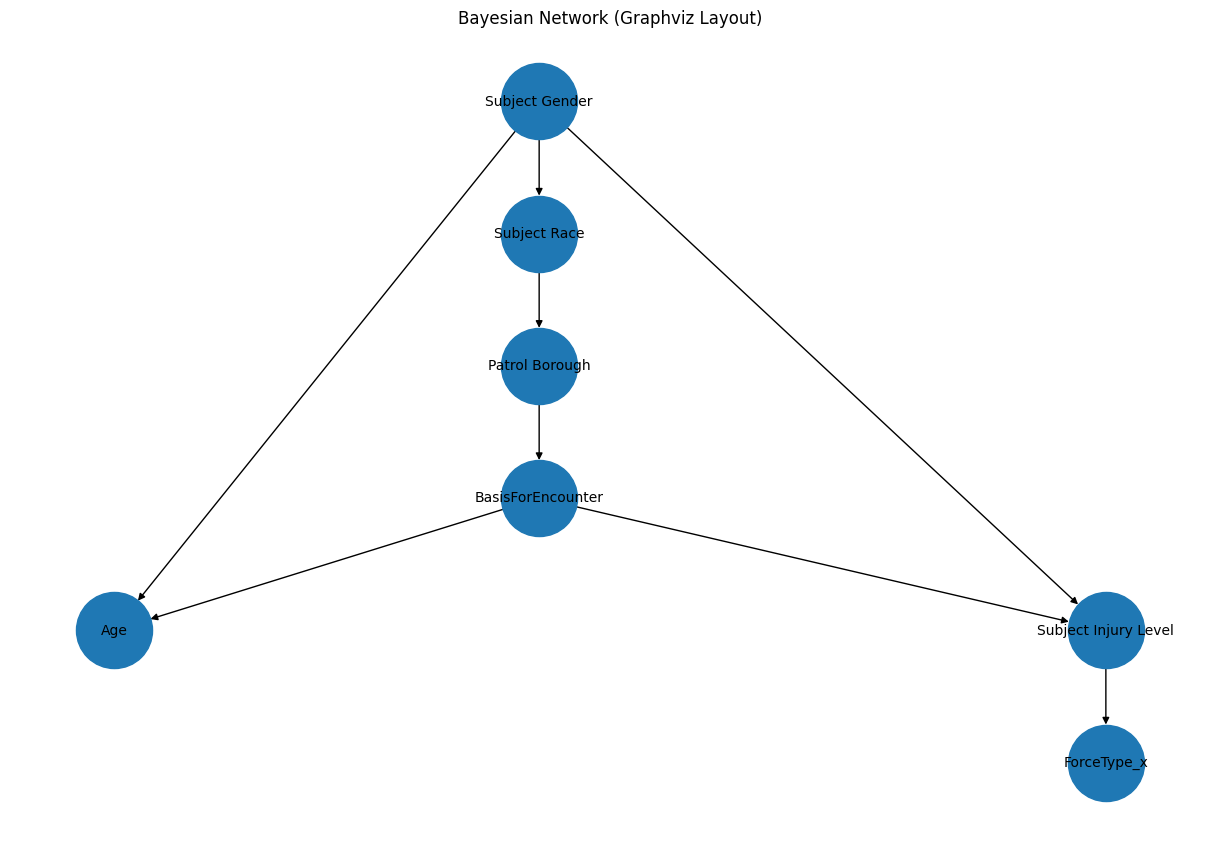

In [ ]:
from networkx.drawing.nx_pydot import graphviz_layout
import matplotlib.pyplot as plt
import networkx as nx

# recreate directed graph from learned structure
G = nx.DiGraph()
G.add_edges_from(model_structure.edges())

plt.figure(figsize=(12, 8))
pos = graphviz_layout(G, prog="dot")

nx.draw(
    G, pos,
    with_labels=True,
    node_size=3000,
    font_size=10,
    arrows=True
)

plt.title("Bayesian Network (Graphviz Layout)")
plt.show()

In [ ]:
print(model_structure.edges())

[('Subject Race', 'Patrol Borough'), ('Subject Gender', 'Subject Race'), ('Subject Gender', 'Age'), ('Subject Gender', 'Subject Injury Level'), ('Patrol Borough', 'BasisForEncounter'), ('BasisForEncounter', 'Age'), ('BasisForEncounter', 'Subject Injury Level'), ('Subject Injury Level', 'ForceType_x')]


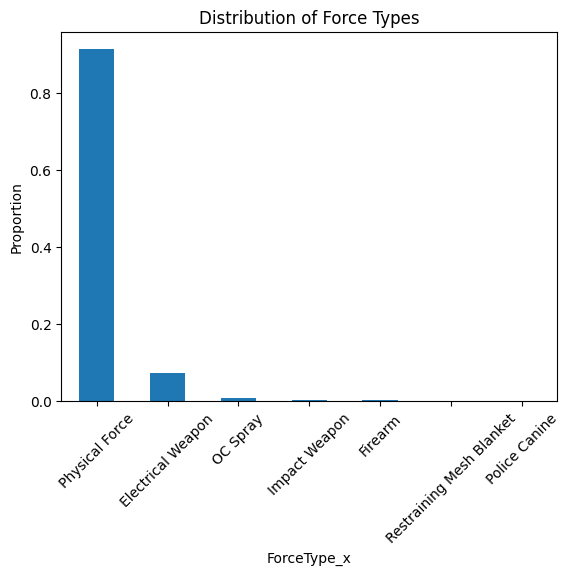

In [ ]:
import matplotlib.pyplot as plt

merged_df["ForceType_x"].value_counts(normalize=True).plot(kind="bar")
plt.title("Distribution of Force Types")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

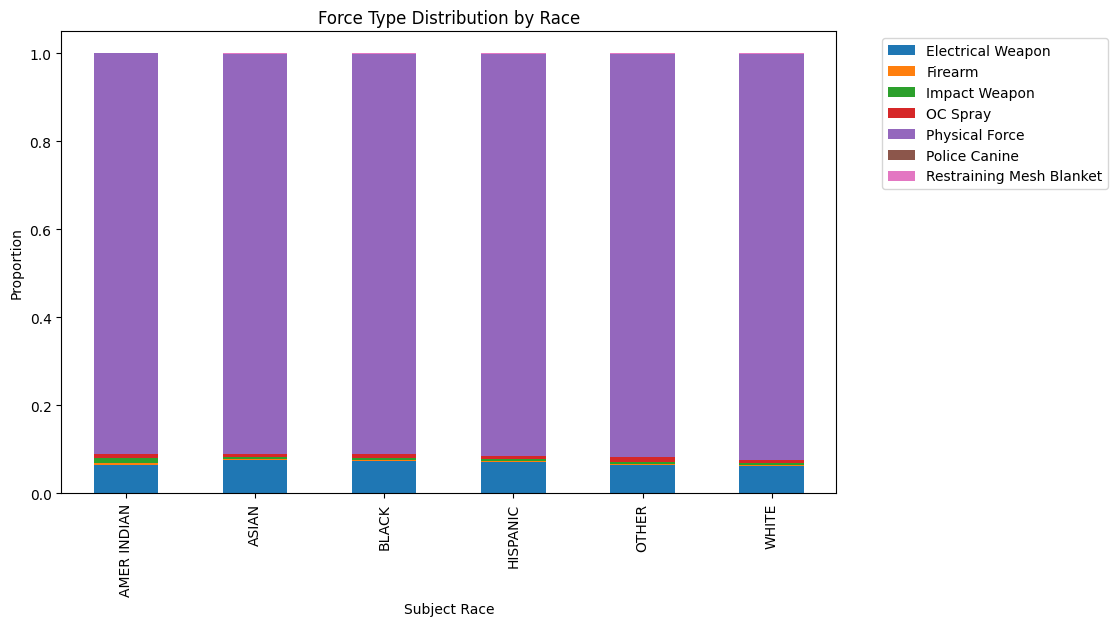

In [ ]:
import seaborn as sns

ct = pd.crosstab(
    merged_df["Subject Race"],
    merged_df["ForceType_x"],
    normalize='index'
)

ct.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Force Type Distribution by Race")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

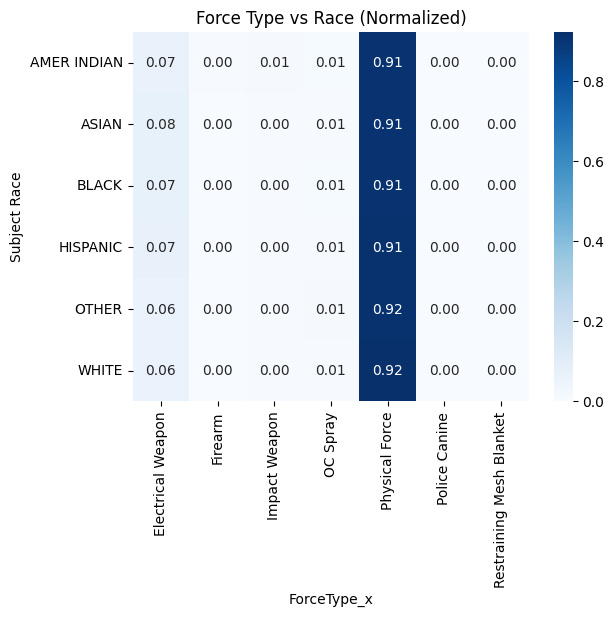

In [ ]:
sns.heatmap(ct, annot=True, cmap="Blues", fmt=".2f")
plt.title("Force Type vs Race (Normalized)")
plt.show()

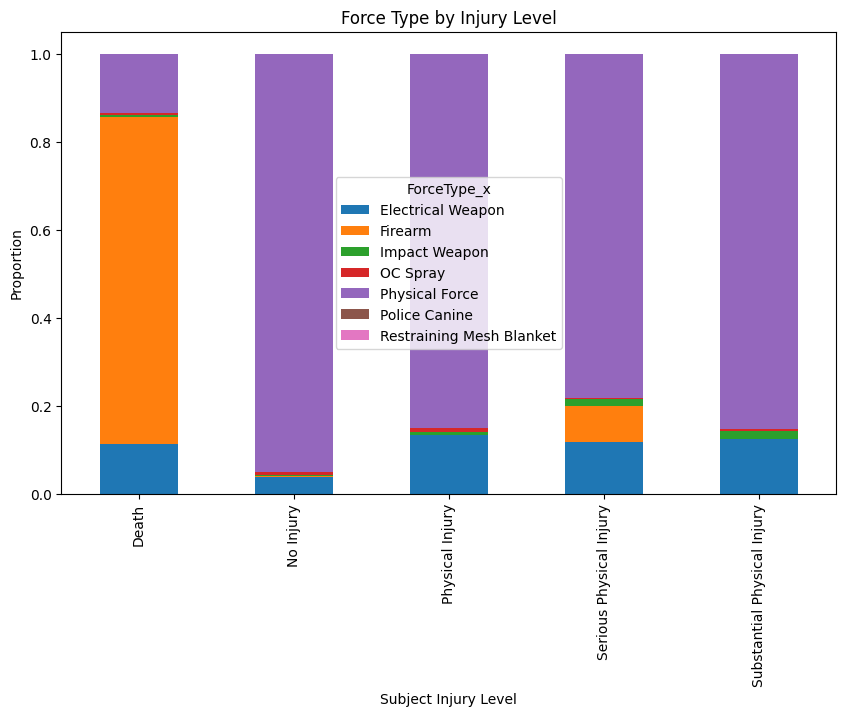

In [ ]:
ct2 = pd.crosstab(
    merged_df["Subject Injury Level"],
    merged_df["ForceType_x"],
    normalize='index'
)

ct2.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Force Type by Injury Level")
plt.ylabel("Proportion")
plt.show()

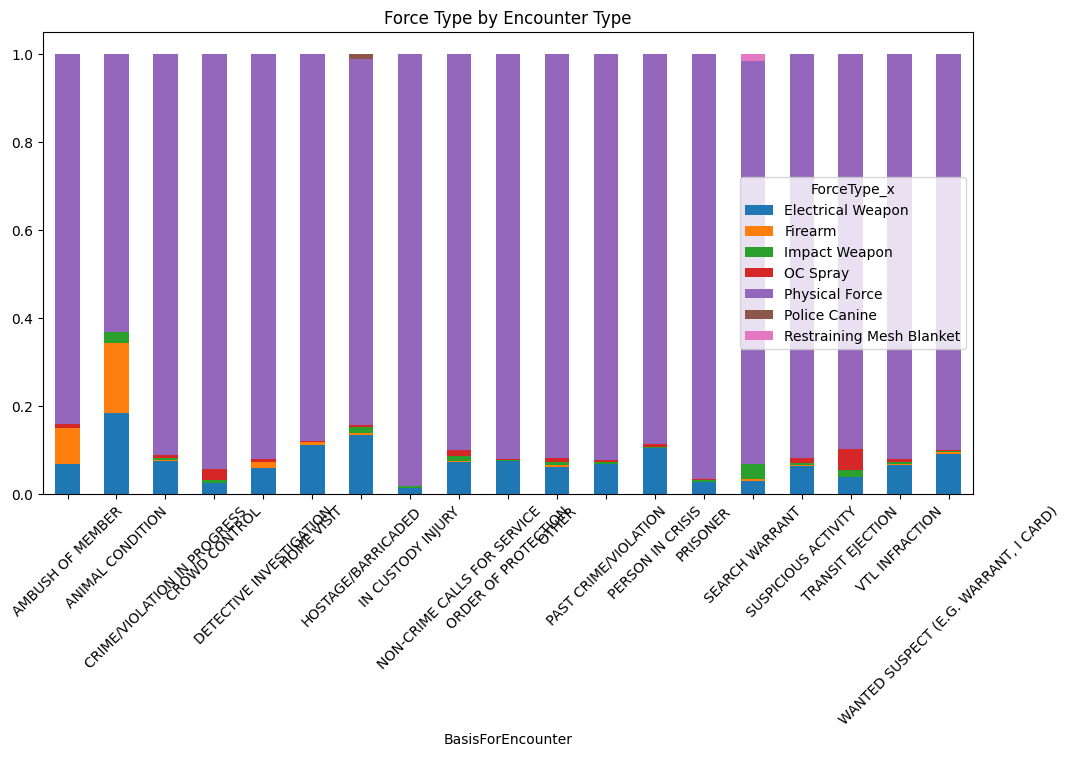

In [ ]:
ct3 = pd.crosstab(
    merged_df["BasisForEncounter"],
    merged_df["ForceType_x"],
    normalize='index'
)

ct3.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Force Type by Encounter Type")
plt.xticks(rotation=45)
plt.show()

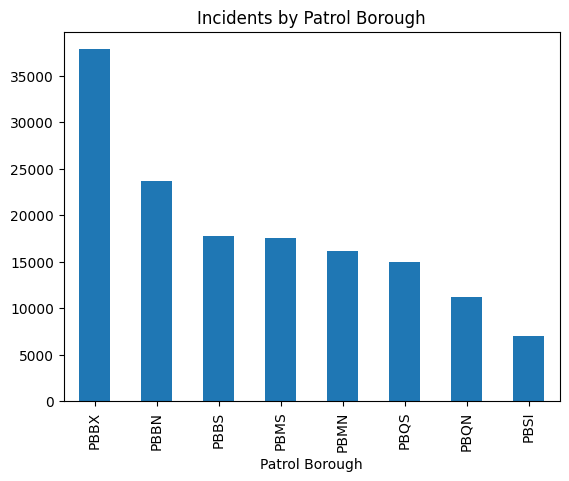

In [ ]:
merged_df["Patrol Borough"].value_counts().plot(kind="bar")
plt.title("Incidents by Patrol Borough")
plt.show()

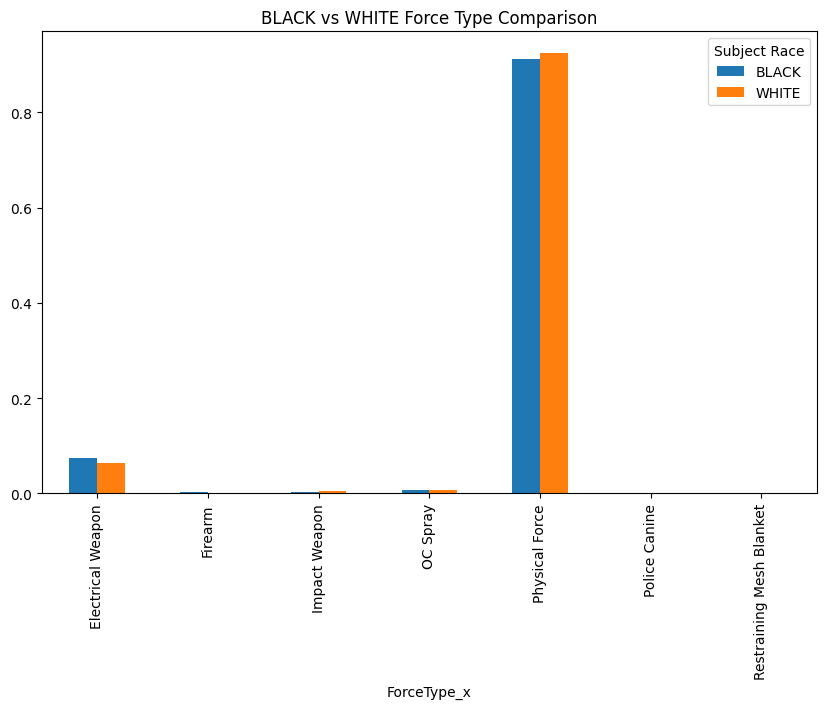

In [ ]:
subset = merged_df[merged_df["Subject Race"].isin(["BLACK", "WHITE"])]

ct_bw = pd.crosstab(
    subset["Subject Race"],
    subset["ForceType_x"],
    normalize='index'
)

ct_bw.T.plot(kind="bar", figsize=(10,6))
plt.title("BLACK vs WHITE Force Type Comparison")
plt.show()

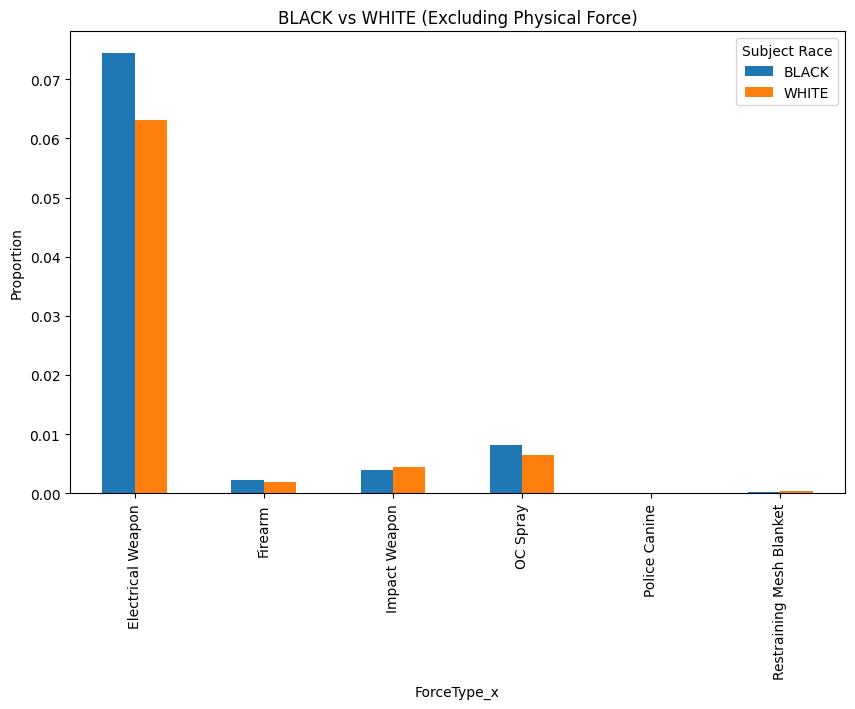

In [ ]:
ct_bw_no_pf = ct_bw.drop(columns=["Physical Force"])

ct_bw_no_pf.T.plot(kind="bar", figsize=(10,6))
plt.title("BLACK vs WHITE (Excluding Physical Force)")
plt.ylabel("Proportion")
plt.show()